# MLDoctor - Case3

For an automated social media tagging system designed to predict whether a person appears young in facial images, the developers implemented a model that assigns a probability score to each prediction. To streamline the workflow, a “High-Confidence Bypass” was added: predictions with a probability of 90% or higher were automatically published without human review. During the controlled “Lab Phase,” this approach performed impressively, producing accurate tags with minimal intervention. Since deployment, however, the system has drawn criticism. In practice, it occasionally publishes incorrect tags while still reporting near-certain confidence, leading to unexpected errors despite the apparent reliability suggested by its high probability outputs. 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import ConfusionMatrixDisplay
from utils import audit_utils

In [2]:
device = audit_utils.setup_env()

internal_path = 'Case3Dataset/test_internal'
external_path = 'Case3Dataset/test_external'

test_internal_loader, test_external_loader, test_internal_dataset, test_external_dataset = audit_utils.get_dataloaders(
    internal_path, external_path, batch_size=16, num_workers=1
)

Using device: cuda:0


Class mapping: {'negative': 0, 'positive': 1}


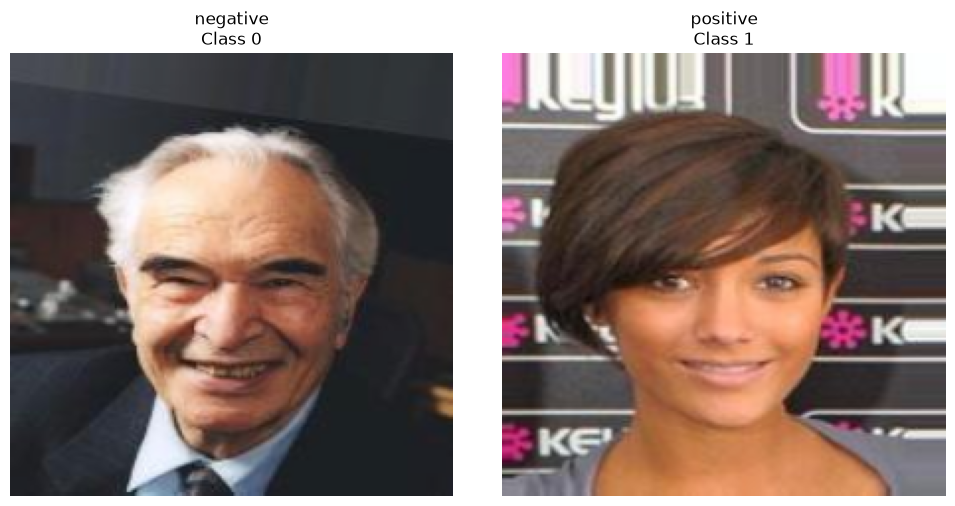

In [3]:
# Check class names and corresponding indices
print("Class mapping:",test_internal_dataset.class_to_idx)

# Display one sample image from each class
fig,axes=plt.subplots(1,len(test_internal_dataset.classes),figsize=(10,5))

for class_idx,class_name in enumerate(test_internal_dataset.classes):
    # Find the first sample belonging to this class
    sample_idx=test_internal_dataset.targets.index(class_idx)
    image,label=test_internal_dataset[sample_idx]

    # Reverse ImageNet normalization for visualization
    image=image.cpu().numpy().transpose(1,2,0)
    image=image*np.array(audit_utils.imagenet_stds)+np.array(audit_utils.imagenet_means)
    image=np.clip(image,0,1)

    axes[class_idx].imshow(image)
    axes[class_idx].set_title(f"{class_name}\nClass {class_idx}")
    axes[class_idx].axis("off")

plt.tight_layout()
plt.show()

In [4]:
resnet_frozen = audit_utils.setup_model(2, "resnet_frozen_best_case3.pth", device)
print(resnet_frozen)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [5]:
all_predictions, all_labels = audit_utils.evaluate_model(resnet_frozen, test_internal_loader, test_external_loader, device)

for split in ['internal', 'external']:
    predicted_classes = np.argmax(all_predictions[split], axis=1)
    accuracy = (predicted_classes == all_labels[split]).mean()
    print(f"{split} set - Accuracy: {accuracy:.3f}")

Evaluating on external set: 100%|██████████| 19/19 [00:00<00:00, 28.68it/s]

internal set - Accuracy: 0.973
external set - Accuracy: 0.593



===== INTERNAL SET =====
Accuracy : 0.973
Precision: 0.973
Recall   : 0.973
F1-score : 0.973


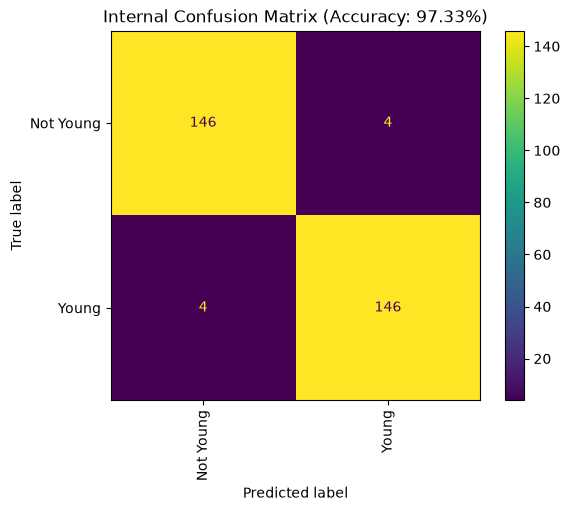


===== EXTERNAL SET =====
Accuracy : 0.593
Precision: 0.561
Recall   : 0.853
F1-score : 0.677


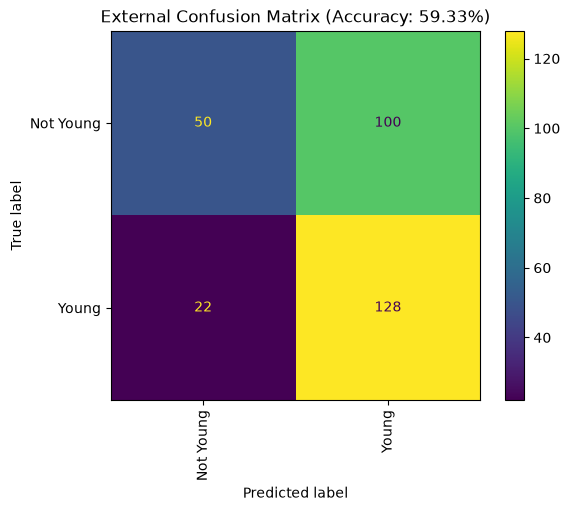

In [6]:
threshold = 0.5
for split in ['internal', 'external']:
    labels = all_labels[split]
    probs_young = all_predictions[split][:, 1]
    preds = probs_young >= threshold

    accuracy = (preds == labels.astype(bool)).mean()
    precision, recall, f1 = audit_utils.compute_metrics(labels, probs_young, threshold=threshold)

    print(f"\n===== {split.upper()} SET =====")
    print(f"Accuracy : {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall   : {recall:.3f}")
    print(f"F1-score : {f1:.3f}")

    # Plot confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        labels, preds, display_labels=['Not Young', 'Young'], xticks_rotation='vertical'
    )
    plt.title(f'{split.capitalize()} Confusion Matrix (Accuracy: {accuracy * 100:.2f}%)')
    plt.savefig(f'plot/case3_cm_{split}.png')
    plt.show()

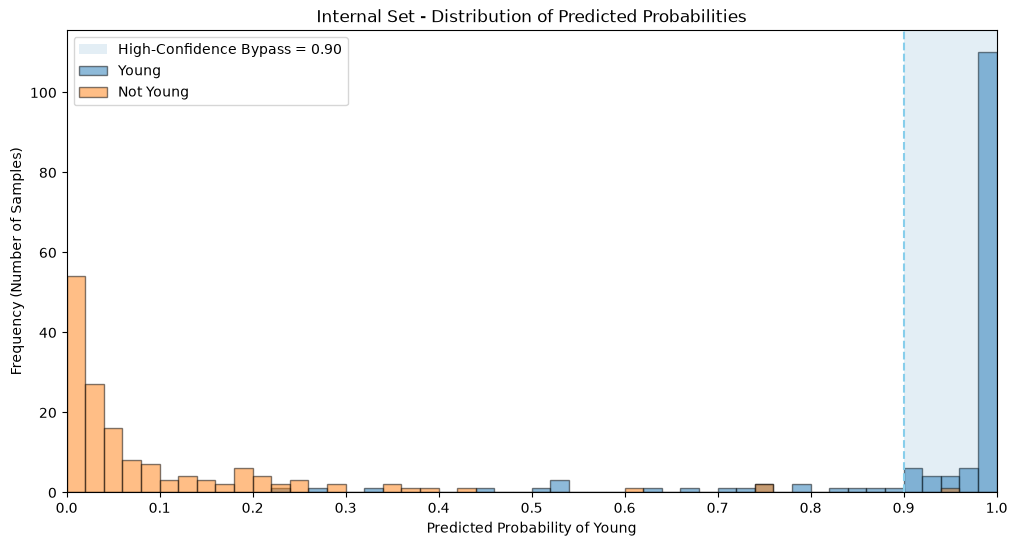

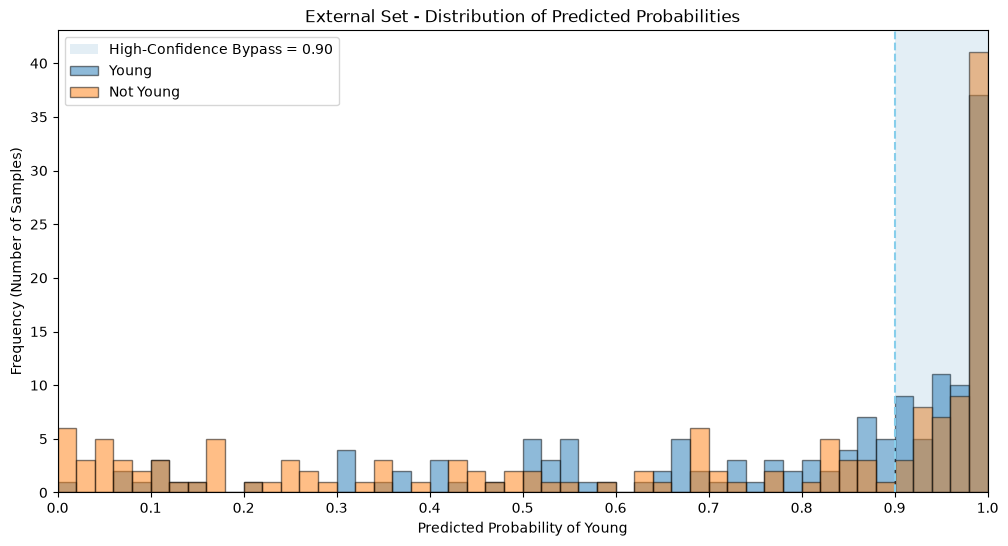

In [7]:
# Plot predicted probability distributions for Internal and External sets
num_bins=50
confidence_threshold=0.9

for split in ['internal','external']:

    # Ground-truth labels: 0 = Not Young, 1 = Young
    labels=all_labels[split].astype(bool)

    # Predicted probability for Young
    probs_young=all_predictions[split][:,1]

    # Separate probabilities by actual class
    young_counts,young_bin_edges=np.histogram(probs_young[labels],bins=num_bins,range=(0,1))
    not_young_counts,not_young_bin_edges=np.histogram(probs_young[~labels],bins=num_bins,range=(0,1))

    # Plot histogram
    plt.figure(figsize=(12,6))
    plt.bar(young_bin_edges[:-1],young_counts,width=young_bin_edges[1]-young_bin_edges[0],edgecolor='black',align='edge',label='Young',alpha=0.5)
    plt.bar(not_young_bin_edges[:-1],not_young_counts,width=not_young_bin_edges[1]-not_young_bin_edges[0],edgecolor='black',align='edge',label='Not Young',alpha=0.5)

    # High-Confidence Bypass
    plt.axvspan(confidence_threshold,1,alpha=0.12,label='High-Confidence Bypass = 0.90')
    plt.axvline(x=confidence_threshold,color='skyblue',linestyle='--',linewidth=1.5)

    plt.xlabel('Predicted Probability of Young')
    plt.ylabel('Frequency (Number of Samples)')
    plt.title(f'{split.capitalize()} Set - Distribution of Predicted Probabilities')
    plt.xticks(np.linspace(0,1,11))
    plt.xlim(0,1)
    plt.legend()
    plt.show()

The predicted probability distributions showed clear separation between the Young and Not Young classes on the internal set. In contrast, the external set contained a substantial number of Not Young samples assigned probabilities above 90% for the Young class, indicating highly confident incorrect predictions.

External Set Expected Calibration Error (ECE): 0.3036


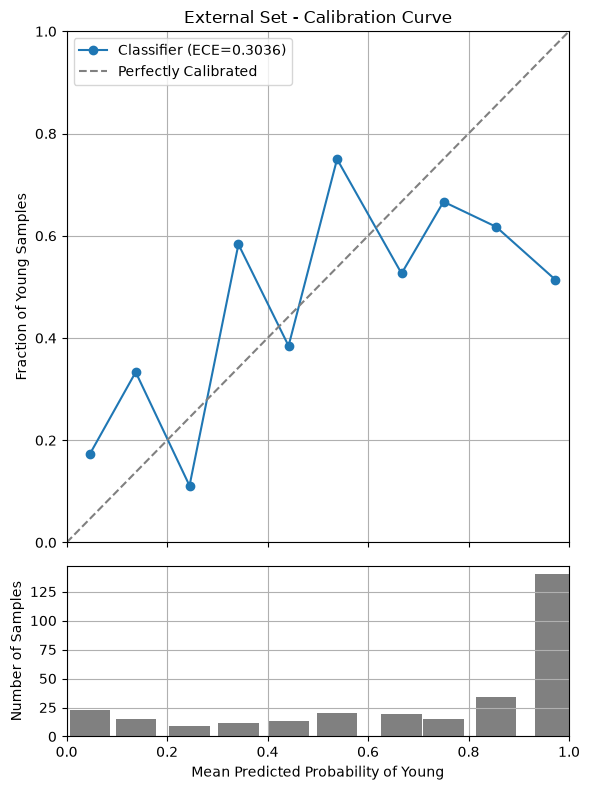

In [8]:
# Calibration Curve and ECE
n_bins = 10
bins = np.linspace(0, 1, n_bins + 1)

labels = all_labels['external'].astype(bool)
probs_young = all_predictions['external'][:,1]

bin_indices = np.digitize(probs_young, bins) - 1
bin_indices = np.clip(bin_indices, 0, n_bins - 1)

bin_true_frac = []
bin_mean_prob = []
bin_counts = []

for i in range(n_bins):
    mask = bin_indices == i
    mask_sum = np.sum(mask)
    bin_counts.append(mask_sum)
    if mask_sum > 0:
        bin_true_frac.append(np.mean(labels[mask]))
        bin_mean_prob.append(np.mean(probs_young[mask]))
    else:
        bin_true_frac.append(np.nan)
        bin_mean_prob.append(np.nan)

bin_true_frac = np.array(bin_true_frac)
bin_mean_prob = np.array(bin_mean_prob)
bin_counts = np.array(bin_counts)

# Calculate ECE
ece = audit_utils.calculate_ece(labels, probs_young, n_bins=10)
print(f"External Set Expected Calibration Error (ECE): {ece:.4f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), sharex=True, gridspec_kw={'height_ratios':[3, 1]})

ax1.plot(bin_mean_prob, bin_true_frac, marker='o', label=f'Classifier (ECE={ece:.4f})')
ax1.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
ax1.set_ylabel('Fraction of Young Samples')
ax1.set_title('External Set - Calibration Curve')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.grid(True)
ax1.legend()

ax2.bar(bin_mean_prob, bin_counts, width=0.08, color='gray')
ax2.set_xlabel('Mean Predicted Probability of Young')
ax2.set_ylabel('Number of Samples')
ax2.set_xlim(0, 1)
ax2.grid(True)

plt.tight_layout()
plt.savefig('plot/case3_calibration.png')
plt.show()

The calibration analysis on the external set showed fluctuations around the perfectly calibrated line, indicating inconsistent alignment between predicted probabilities and the observed fraction of Young samples. In particular, pronounced overconfidence was observed in the High-Confidence Bypass region above 90%, where the calibration curve fell substantially below the perfectly calibrated line. This indicates that high-confidence predictions became unreliable after deployment.

In [9]:
# High-Confidence Bypass
labels = all_labels['external']
probs_young = all_predictions['external'][:, 1]
high_conf_mask = probs_young >= 0.9

high_conf_probs = probs_young[high_conf_mask]
high_conf_labels = labels[high_conf_mask]

high_conf_total = len(high_conf_labels)
high_conf_correct = np.sum(high_conf_labels == 1)
high_conf_incorrect = np.sum(high_conf_labels == 0)
high_conf_accuracy = high_conf_correct / high_conf_total if high_conf_total > 0 else 0

print("===== EXTERNAL HIGH-CONFIDENCE BYPASS =====")
print(f"Total bypassed predictions : {high_conf_total}")
print(f"Correct Young predictions  : {high_conf_correct}")
print(f"Incorrect Not Young samples: {high_conf_incorrect}")
print(f"Bypass accuracy            : {high_conf_accuracy:.3f}")

===== EXTERNAL HIGH-CONFIDENCE BYPASS =====
Total bypassed predictions : 140
Correct Young predictions  : 72
Incorrect Not Young samples: 68
Bypass accuracy            : 0.514


Among the 140 external predictions that entered the High-Confidence Bypass, only 72 were actually Young, resulting in a bypass accuracy of 51.4%.
   
The remaining 68 Not Young samples would therefore have been incorrectly tagged as Young and automatically published without human review.

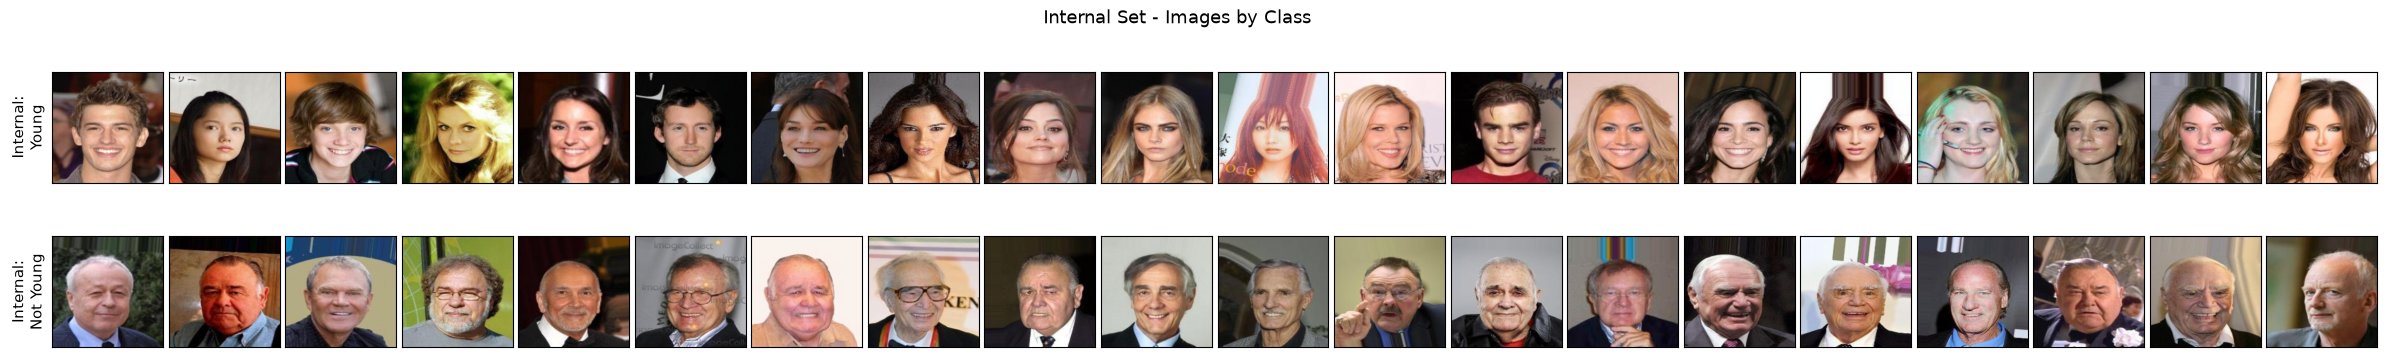

In [10]:
# Select 20 samples from each class for Internal set
np.random.seed(0)

internal_labels=all_labels['internal']

internal_young=np.where(internal_labels==1)[0]
internal_not_young=np.where(internal_labels==0)[0]

selected_internal_young=np.random.choice(internal_young,20,replace=False)
selected_internal_not_young=np.random.choice(internal_not_young,20,replace=False)

# Denormalize images for visualization
def denormalize_image(image):
    image=image.numpy().transpose(1,2,0)
    image=image*np.array(audit_utils.imagenet_stds)+np.array(audit_utils.imagenet_means)
    return np.clip(image,0,1)

# Create figure
fig,axes=plt.subplots(2,20,figsize=(30,4))

# Internal - Young
for col,idx in enumerate(selected_internal_young):
    image,label=test_internal_dataset[idx]
    axes[0,col].imshow(denormalize_image(image))
    axes[0,col].set_xticks([])
    axes[0,col].set_yticks([])

# Internal - Not Young
for col,idx in enumerate(selected_internal_not_young):
    image,label=test_internal_dataset[idx]
    axes[1,col].imshow(denormalize_image(image))
    axes[1,col].set_xticks([])
    axes[1,col].set_yticks([])

# Labels
axes[0,0].set_ylabel('Internal:\nYoung',fontsize=11)
axes[1,0].set_ylabel('Internal:\nNot Young',fontsize=11)

plt.suptitle('Internal Set - Images by Class',fontsize=13)

plt.subplots_adjust(
    hspace=0.25,
    wspace=0.05,
    top=0.85
)

plt.show()

Visual inspection of the internal dataset suggests a strong association between the target labels and appearance-related characteristics. The Not Young class predominantly consists of older male-presenting individuals, with many images showing limited hair and exposed foreheads, whereas the Young class includes both female-presenting and younger male-presenting individuals.

High-confidence Young samples: 72
High-confidence Not Young samples: 68
Low-probability Young samples: 22
Low-probability Not Young samples: 50


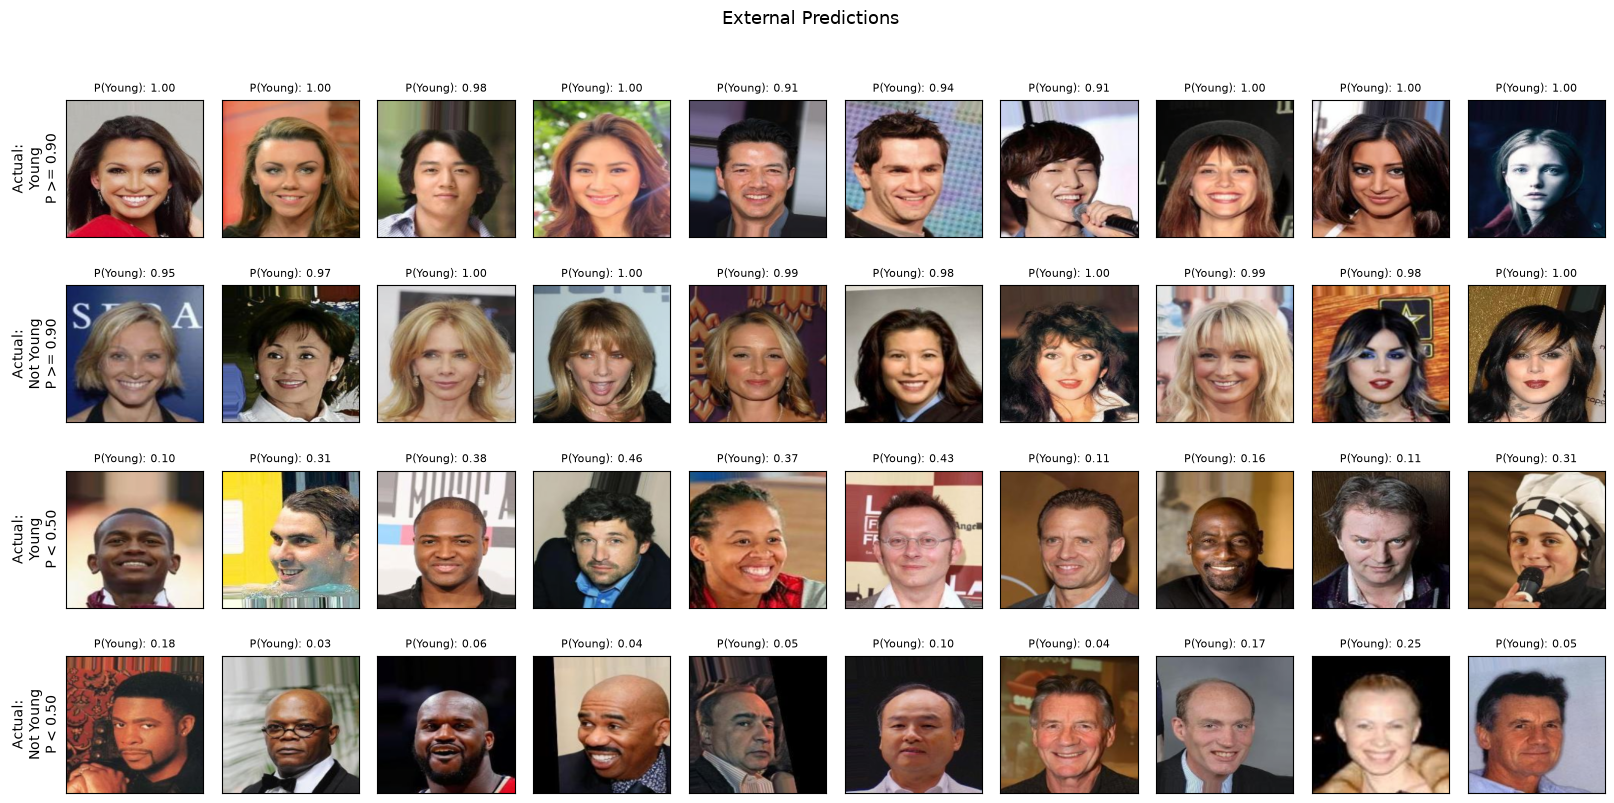

In [11]:
# Get external labels and predicted probabilities
labels=all_labels['external']
probs_young=all_predictions['external'][:,1]

# Identify samples
high_conf_young=np.where((labels==1)&(probs_young>=0.9))[0]
high_conf_not_young=np.where((labels==0)&(probs_young>=0.9))[0]

low_prob_young=np.where((labels==1)&(probs_young<0.5))[0]
low_prob_not_young=np.where((labels==0)&(probs_young<0.5))[0]

print(f'High-confidence Young samples: {len(high_conf_young)}')
print(f'High-confidence Not Young samples: {len(high_conf_not_young)}')
print(f'Low-probability Young samples: {len(low_prob_young)}')
print(f'Low-probability Not Young samples: {len(low_prob_not_young)}')

# Select 10 samples from each group
np.random.seed(0)

selected_young=np.random.choice(high_conf_young,10,replace=False)
selected_not_young=np.random.choice(high_conf_not_young,10,replace=False)

selected_low_young=np.random.choice(low_prob_young,10,replace=False)
selected_low_not_young=np.random.choice(low_prob_not_young,10,replace=False)

# Denormalize images for visualization
def denormalize_image(image):
    image=image.cpu().numpy().transpose(1,2,0) if hasattr(image, 'cpu') else image.numpy().transpose(1,2,0)
    image=image*np.array(audit_utils.imagenet_stds)+np.array(audit_utils.imagenet_means)
    return np.clip(image,0,1)

# Create figure
fig,axes=plt.subplots(4,10,figsize=(20,9))

# High-confidence actual Young
for col,idx in enumerate(selected_young):
    image,label=test_external_dataset[idx]
    axes[0,col].imshow(denormalize_image(image))
    axes[0,col].set_title(f'P(Young): {probs_young[idx]:.2f}',fontsize=8)
    axes[0,col].set_xticks([])
    axes[0,col].set_yticks([])

# High-confidence actual Not Young
for col,idx in enumerate(selected_not_young):
    image,label=test_external_dataset[idx]
    axes[1,col].imshow(denormalize_image(image))
    axes[1,col].set_title(f'P(Young): {probs_young[idx]:.2f}',fontsize=8)
    axes[1,col].set_xticks([])
    axes[1,col].set_yticks([])

# Low-probability actual Young
for col,idx in enumerate(selected_low_young):
    image,label=test_external_dataset[idx]
    axes[2,col].imshow(denormalize_image(image))
    axes[2,col].set_title(f'P(Young): {probs_young[idx]:.2f}',fontsize=8)
    axes[2,col].set_xticks([])
    axes[2,col].set_yticks([])

# Low-probability actual Not Young
for col,idx in enumerate(selected_low_not_young):
    image,label=test_external_dataset[idx]
    axes[3,col].imshow(denormalize_image(image))
    axes[3,col].set_title(f'P(Young): {probs_young[idx]:.2f}',fontsize=8)
    axes[3,col].set_xticks([])
    axes[3,col].set_yticks([])

# Labels
axes[0,0].set_ylabel('Actual:\nYoung\nP >= 0.90',fontsize=10)
axes[1,0].set_ylabel('Actual:\nNot Young\nP >= 0.90',fontsize=10)
axes[2,0].set_ylabel('Actual:\nYoung\nP < 0.50',fontsize=10)
axes[3,0].set_ylabel('Actual:\nNot Young\nP < 0.50',fontsize=10)

plt.suptitle('External Predictions',fontsize=13)
plt.subplots_adjust(hspace=0.35,wspace=0.05,top=0.88)
plt.savefig('plot/case3_predictions.png')
plt.show()



Visual inspection of the external high-confidence predictions further showed that most female-presenting Not Young samples were incorrectly assigned high probabilities above 90% for the Young class, while female-presenting samples with more exposed foreheads and limited hair coverage were instead assigned probabilities below 0.50 for the Young class, suggesting that the model may have relied on demographic and appearance-related features rather than robust age-related facial characteristics.

## Evaluation Processing Reasoning
While we compute standard metrics (Accuracy, ROC-AUC), the primary focus for an automated bypass system is the reliability of the model's confidence scores. We plot the predicted probability distributions to see the spread of confidences. We then construct a Reliability Diagram (Calibration Curve) and compute the Expected Calibration Error (ECE) to quantify exactly how much the model's reported confidence deviates from its actual empirical accuracy.

## Diagnosis

The model is miscalibrated and overconfident. Internal data also showed class-specific differences in age, gender, and 
appearance that differed from the external data. These issues make the 90% High-Confidence Bypass unreliable for automated publishing.

## Evidence

1. **Performance:** Accuracy decreased from 97.3% to 59.3% on the external dataset, with 100 FPs and 22 FNs. The dominant error was Not Young individuals being incorrectly classified as Young.

2. **Dataset Composition:** Internal Not Young samples were predominantly older men, often with limited hair coverage and exposed foreheads, while Young samples included younger men and women across a broader age range. This pattern differed in the external data, suggesting that class-specific appearance patterns may not generalize to deployment.

3. **Probability Distribution:** Internal predictions showed clear separation between Young and Not Young, whereas external distributions substantially overlapped. Many Not Young samples exceeded the 90% Young threshold, showing that 
high confidence did not reliably indicate correct predictions in deployment.

4. **Calibration & Bypass:** External calibration showed ECE = 0.3036 and clear overconfidence above 90%. Of 140 predictions exceeding the bypass threshold, 68 were incorrect, resulting in only 51.4% bypass accuracy. These high-confidence errors are also illustrated across the external classes.

## Recommendations
1. **Temperature Scaling**: Implement Temperature Scaling (a post-hoc calibration technique) on the validation set to soften the softmax probabilities and bring the model's confidence scores in line with empirical accuracy.
2. **Label Smoothing**: In future training runs, apply label smoothing to the loss function to prevent the network from becoming overly confident in its predictions.
3. **Re-evaluate the Bypass Threshold**: After calibration (e.g., via Temperature Scaling), the 90% threshold must be re-validated. It may need to be adjusted higher (e.g., 98%) to achieve the desired true positive rate for the automated publishing pipeline.